# Predicting Housing Prices Using Linear-Regression Model

## 🏠 House Price Prediction with Linear Regression

This project uses the Ames Housing dataset to build a linear regression model that predicts house prices based on various features. The workflow includes data exploration, cleaning, feature engineering (e.g., total square footage, house age), and encoding of categorical variables. The model's performance is evaluated using RMSE and R-squared. To improve prediction accuracy, outlier sale prices below \$50,000 and above \$500,000 were excluded from the dataset.


#### Import libraries


In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [256]:
#Read in csv data
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### 1. Explore the Data

In [257]:
df.shape

(1460, 81)

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [259]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### 2. Data cleaning and Transformation

In [260]:
#Keeping Important columns for making predictions
columns_to_keep = [
     'BldgType','OverallCond', 'YearBuilt','YrSold', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'FullBath','BsmtFullBath','BedroomAbvGr',
    'GarageCars', 'SalePrice']
df = df[columns_to_keep]
df.head()

,BldgType,OverallCond,YearBuilt,YrSold,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,BsmtFullBath,BedroomAbvGr,GarageCars,SalePrice
0,1Fam,5,2003,2008,856,856,854,2,1,3,2,208500
1,1Fam,8,1976,2007,1262,1262,0,2,0,3,2,181500
2,1Fam,5,2001,2008,920,920,866,2,1,3,2,223500
3,1Fam,5,1915,2006,756,961,756,1,1,3,3,140000
4,1Fam,5,2000,2008,1145,1145,1053,2,1,4,3,250000


#### 3. Feature Engineering

In [261]:
#Create Total Square Feet Column
df['TotalSqFt'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df.head()

,BldgType,OverallCond,YearBuilt,YrSold,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,BsmtFullBath,BedroomAbvGr,GarageCars,SalePrice,TotalSqFt
0,1Fam,5,2003,2008,856,856,854,2,1,3,2,208500,2566
1,1Fam,8,1976,2007,1262,1262,0,2,0,3,2,181500,2524
2,1Fam,5,2001,2008,920,920,866,2,1,3,2,223500,2706
3,1Fam,5,1915,2006,756,961,756,1,1,3,3,140000,2473
4,1Fam,5,2000,2008,1145,1145,1053,2,1,4,3,250000,3343


In [262]:
#Create Age Column
df['Age'] = df['YrSold'] - df['YearBuilt']
df.head()

,BldgType,OverallCond,YearBuilt,YrSold,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,BsmtFullBath,BedroomAbvGr,GarageCars,SalePrice,TotalSqFt,Age
0,1Fam,5,2003,2008,856,856,854,2,1,3,2,208500,2566,5
1,1Fam,8,1976,2007,1262,1262,0,2,0,3,2,181500,2524,31
2,1Fam,5,2001,2008,920,920,866,2,1,3,2,223500,2706,7
3,1Fam,5,1915,2006,756,961,756,1,1,3,3,140000,2473,91
4,1Fam,5,2000,2008,1145,1145,1053,2,1,4,3,250000,3343,8


In [263]:
#Create Bathrooms Column
df['Bathrooms'] = df['BsmtFullBath'] + df['FullBath']
df.head()

,BldgType,OverallCond,YearBuilt,YrSold,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,BsmtFullBath,BedroomAbvGr,GarageCars,SalePrice,TotalSqFt,Age,Bathrooms
0,1Fam,5,2003,2008,856,856,854,2,1,3,2,208500,2566,5,3
1,1Fam,8,1976,2007,1262,1262,0,2,0,3,2,181500,2524,31,2
2,1Fam,5,2001,2008,920,920,866,2,1,3,2,223500,2706,7,3
3,1Fam,5,1915,2006,756,961,756,1,1,3,3,140000,2473,91,2
4,1Fam,5,2000,2008,1145,1145,1053,2,1,4,3,250000,3343,8,3


In [264]:
#Rename Bedroom column
df.rename(columns={'BedroomAbvGr': 'Bedrooms'}, inplace=True)
df.head()

,BldgType,OverallCond,YearBuilt,YrSold,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,BsmtFullBath,Bedrooms,GarageCars,SalePrice,TotalSqFt,Age,Bathrooms
0,1Fam,5,2003,2008,856,856,854,2,1,3,2,208500,2566,5,3
1,1Fam,8,1976,2007,1262,1262,0,2,0,3,2,181500,2524,31,2
2,1Fam,5,2001,2008,920,920,866,2,1,3,2,223500,2706,7,3
3,1Fam,5,1915,2006,756,961,756,1,1,3,3,140000,2473,91,2
4,1Fam,5,2000,2008,1145,1145,1053,2,1,4,3,250000,3343,8,3


In [265]:
#Drop Irrelevant Columns
df.drop(['1stFlrSF', '2ndFlrSF','TotalBsmtSF','BsmtFullBath','FullBath', 'YearBuilt', 'YrSold'], axis=1, inplace=True)
df.head()


,BldgType,OverallCond,Bedrooms,GarageCars,SalePrice,TotalSqFt,Age,Bathrooms
0,1Fam,5,3,2,208500,2566,5,3
1,1Fam,8,3,2,181500,2524,31,2
2,1Fam,5,3,2,223500,2706,7,3
3,1Fam,5,3,3,140000,2473,91,2
4,1Fam,5,4,3,250000,3343,8,3


In [266]:
#Reorder Columns
df = df[['BldgType','TotalSqFt','OverallCond','Bedrooms','Bathrooms','Age','GarageCars','SalePrice']]
df.head()


,BldgType,TotalSqFt,OverallCond,Bedrooms,Bathrooms,Age,GarageCars,SalePrice
0,1Fam,2566,5,3,3,5,2,208500
1,1Fam,2524,8,3,2,31,2,181500
2,1Fam,2706,5,3,3,7,2,223500
3,1Fam,2473,5,3,2,91,3,140000
4,1Fam,3343,5,4,3,8,3,250000


In [267]:
#One-hot-encode BldgType
df_encoded = pd.get_dummies(df, columns=['BldgType'], drop_first=True)
df = df_encoded
df.head()




,TotalSqFt,OverallCond,Bedrooms,Bathrooms,Age,GarageCars,SalePrice,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
0,2566,5,3,3,5,2,208500,False,False,False,False
1,2524,8,3,2,31,2,181500,False,False,False,False
2,2706,5,3,3,7,2,223500,False,False,False,False
3,2473,5,3,2,91,3,140000,False,False,False,False
4,3343,5,4,3,8,3,250000,False,False,False,False


#### 4. Check if Linear Model is appropriate using Residual Plot

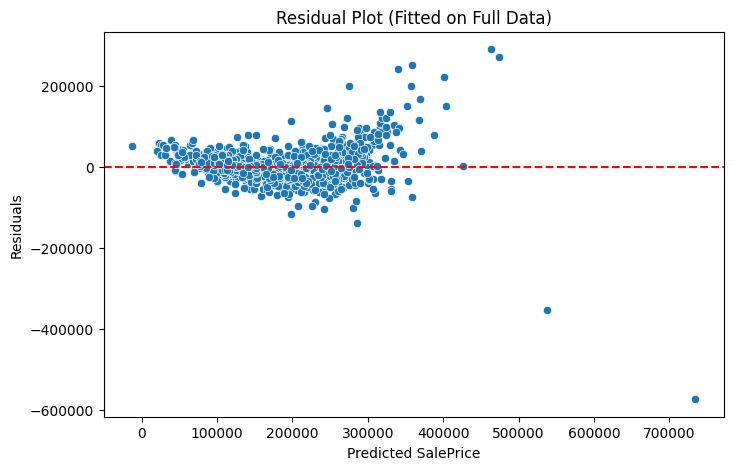

In [268]:
# Separate features and target
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Fit a basic linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict using the same data (just for diagnostic purposes)
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred

# Plot residuals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residual Plot (Fitted on Full Data)")
plt.show()

#####       Residuals are randomly spread out except a few extreme outliers, so we can use a Linear Model.

#### 5. Train the Model

In [269]:
df.head()

,TotalSqFt,OverallCond,Bedrooms,Bathrooms,Age,GarageCars,SalePrice,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
0,2566,5,3,3,5,2,208500,False,False,False,False
1,2524,8,3,2,31,2,181500,False,False,False,False
2,2706,5,3,3,7,2,223500,False,False,False,False
3,2473,5,3,2,91,3,140000,False,False,False,False
4,3343,5,4,3,8,3,250000,False,False,False,False


In [270]:
#Split my data into to testing and training sets
X = df.drop('SalePrice', axis = 1)
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state= 42)

In [271]:
#Train model using training set
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [272]:
#Predict on the test set
y_pred = model.predict(X_test)

#### 6. Evaluate the Model

In [273]:
#Calculate RMSE and R² values
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {mse**0.5:.2f}, R²: {r2:.4f}")

RMSE: 40864.30, R²: 0.7823


#### The RMSE tells us that on average this model's predictions are off by $40,864.30. This is a moderte error.

#### The R² value tells us that this model explains about 78.2% of the variance in house prices.

#### 7. Improve Model by Reducing effect of Outliers

In [274]:
#Remove houses priced below 50k or above 500k (adjust to your range)
df2 = df[(df['SalePrice'] > 50000) & (df['SalePrice'] < 500000)]


In [275]:
#Split model

X = df2.drop('SalePrice', axis = 1)
X = X.astype(int)
y = df2['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state= 42)

#Train model using training set
model = LinearRegression()
model.fit(X_train,y_train)

#Predict on the test set
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {mse**0.5:.2f}, R²: {r2:.4f}")

RMSE: 26915.04, R²: 0.8124


#### The RMSE tells us that on average this model's predictions are off by $27,490.45. This is more accurate than our previous model which had an RMSE of over $40,000.        The R² value tells us that this model explains about 81.49% of the variance in house prices.

#### 8. Predict House Price for an example 1-Family house

In [276]:
sample_house = {
    'TotalSqFt': 4000,
    'OverallCond': 8,
    'Bedrooms': 3,
    'Bathrooms': 2,
    'Age': 15,
    'GarageCars': 2,
    'BldgType_2fmCon': 0,
    'BldgType_Duplex': 0,
    'BldgType_Twnhs': 0,  # 1Fam is implied here
    'BldgType_TwnhsE': 0
}

sample_df = pd.DataFrame([sample_house])
predicted_price = model.predict(sample_df)[0]
print(f"Predicted Sale Price: ${predicted_price:,.2f}")


Predicted Sale Price: $288,891.86


## Overall, this model predicts House Prices from Ames Iowa farily accurately.